# Development of a Software Tool for Phonocardiogram Signal Processing

**Author:** Aleksandr Rizov
**Course Project**  
**Date:**17 March 2026

## Introduction
Medical research plays an important role in understanding diseases and in developing effective diagnostic and treatment methods. One of the tools used in cardiology is the phonocardiogram (PCG).

A phonocardiogram is a method of recording heart sounds produced during the cardiac cycle. It can be used for detecting various heart conditions and for monitoring the functioning of the cardiovascular system.

The purpose of this project is to develop a Python-based algorithm for the automatic processing of phonocardiogram data. The algorithm should identify the beginning, the peak, and the end of the first heart sound in each cardiac cycle.


## Problem Statement

The sampling frequency is 1000 Hz, which means that the time interval between adjacent samples is 1 millisecond.

The goal of the project is to create an algorithm that automatically detects the first heart sound in each cardiac cycle and returns the result as a list of triplets:

$\[
[t_1, t_2, t_3]
\]$

where:

- $\( t_1 \) $is the beginning of the first heart sound,
- $\( t_2 \)$ is the point of maximum amplitude,
- $\( t_3 \)$ is the end of the first heart sound.

The result should also be visualized on a graph.

$\[
[t_1, t_2, t_3]
\]$

where:

- $\( t_1 \)$ is the beginning of the first heart tone,
- $\( t_2 \)$ is the point of maximum amplitude,
- $\( t_3 \)$ is the end of the first heart tone.

The result should also be visualized on a graph.

## Relevance of the Project

The relevance of this project lies in the possibility of applying automated phonocardiogram analysis in medical practice and in large-scale research related to heart diagnostics.

Cardiovascular diseases remain one of the leading causes of death worldwide, which makes the development of signal-processing tools for heart monitoring highly important.


## Background: Phonocardiogram

A phonocardiogram is a graphical representation of the sounds produced by the heart. The two main heart sounds are:

*S1* — the first heart sound, associated with the closure of the mitral and tricuspid valves

*S2* — the second heart sound, associated with the closure of the aortic and pulmonary valves

The first heart sound *(S1)* is generally lower in frequency and has a higher amplitude than some other signal components. A phonocardiogram can also contain noise and artifacts, which makes automatic analysis more difficult.

## Signal Processing Concepts

### Discretization

The phonocardiogram is represented as a discrete-time signal. If the sampling frequency is denoted by \( f_s \), then the time step is

$\[
\Delta t = \frac{1}{f_s}
\]$

In this project:

$\[
f_s = 1000 \text{ Hz}
\]$

which means that one sample corresponds to 1 millisecond.

### Signal Centering

To remove the constant component of the signal, centering is applied:

$\[
x_{sh}(n) = x(n) - M_x
\]$

where $\( M_x \)$ is the mean value of the signal.

### Envelope Extraction

To make the algorithm more stable, the absolute value of the centered signal is used:

$\[
x_t(n) = |x(n)|
\]$

### Moving Average

To suppress high-frequency components, a moving average filter is applied:

$\[
P(n) = \frac{1}{w}\sum_{m=0}^{w-1} x(n+m)
\]$

where $\( w \)$ is the window length.

### Thresholding

Noise suppression is performed using the following threshold:

$\[
cutoffValue = \frac{m+s}{k}
\]$

where:

- $\( m \)$ is the mean value,
- $\( s \)$ is the standard deviation,
- $\( k \)$ is an experimentally chosen coefficient.

### Frequency Analysis

For additional signal analysis, the Fast Fourier Transform (FFT) can be used:

$\[
S(k)=\frac{1}{N}\sum_{n=0}^{N-1} s(n)e^{-j2\pi nk/N}
\]$

In [114]:
import os
import numpy as np
import matplotlib.pyplot as plt

## 3Data Loading

Using the tools of the Python programming language, the data are extracted and visualized. The data from a sample phonocardiogram were extracted and prepared for visualization and further processing.

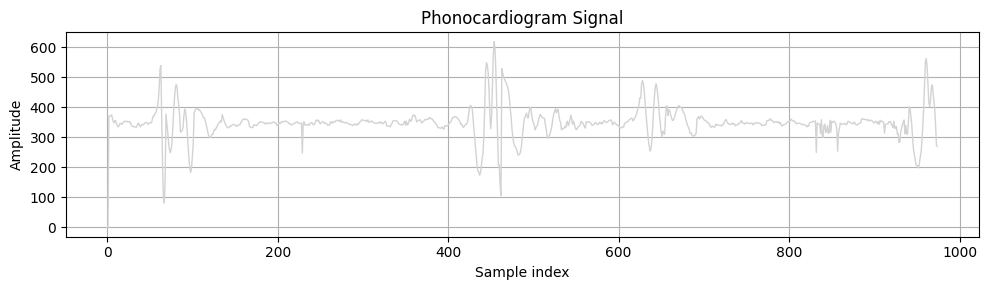

In [190]:
import numpy as np
import matplotlib.pyplot as plt

raw = """0;4;371;371;371;375;367;354;348;356;355;347;338;335;339;
346;347;343;346;351;352;354;352;354;352;353;351;352;342;338;337;335;336;335;333;338;346;
347;339;335;341;343;341;344;347;349;350;347;343;347;349;348;349;360;371;371;379;382;
391;403;422;464;528;539;362;209;101;81;151;378;349;318;284;260;249;259;281;329;385;432;464;
477;466;429;408;375;318;319;323;333;371;394;383;359;316;272;227;195;183;198;237;279;381;389;
394;396;396;391;393;388;385;380;373;366;366;356;343;333;318;307;303;299;303;310;310;320;
327;325;332;337;343;348;349;356;351;376;367;358;348;343;338;333;332;333;338;337;
340;342;343;343;341;338;337;341;341;341;344;350;353;360;360;362;359;361;359;358;351;
337;334;332;334;334;342;340;341;339;341;345;348;351;352;351;351;349;348;345;348;345;348;348;
347;346;349;348;349;352;351;348;348;340;341;343;349;346;349;353;351;352;
354;353;354;352;351;346;346;345;341;343;344;346;347;350;350;352;349;346;347;348;346;248;347;
352;341;342;341;342;344;340;346;349;347;348;341;343;348;357;358;354;357;350;345;348;351;353;
351;346;348;347;344;340;342;341;352;350;347;353;351;351;355;357;356;355;357;353;358;350;351;
352;349;348;350;348;348;346;343;343;343;342;340;340;344;345;342;341;346;344;350;352;355;359;
357;357;356;355;357;353;358;350;351;352;355;353;351;348;349;347;346;347;349;350;347;352;349;345;347;
350;354;351;338;338;338;337;335;341;345;354;355;355;356;355;355;350;346;344;342;343;341;343;
347;354;341;354;341;343;354;361;353;356;367;375;372;373;365;352;353;357;357;359;354;348;351;354;356;360;
359;359;362;361;366;365;362;362;359;353;352;347;344;339;333;332;332;330;332;335;329;327;339;337;338;338;
341;345;348;352;357;365;365;369;369;368;368;363;361;356;351;343;344;337;333;338;341;
343;346;354;374;396;406;404;400;375;337;305;274;237;207;187;185;174;182;205;233;246;313;400;523;549;540;515;460;
378;329;368;468;573;619;597;523;421;308;208;209;142;106;529;515;504;496;488;484;474;466;451;427;393;
365;326;300;281;272;269;262;252;241;242;244;253;269;299;328;355;366;373;381;367;364;383;401;397;376;
357;349;342;325;331;338;341;358;368;376;373;367;365;365;363;343;331;305;297;305,307;317;326;344;362;379;388;396;
382;390;394;373;356;350;325;330;328;330;337;333;347;354;339;346;359;374;363;344;354;346;333;327;326;333;336;
337;343;353;350;348;341;338;331;352;350;351;352;350;349;344;340;341;343;347;350;347;343;343;347;
351;346;349;345;351;356;354;350;349;351;354;356;357;358;354;342;347;351;347;345;341;340;338;335;331;332;
334;335;334;347;348;350;351;354;357;359;361;364;363;355;359;365;370;377;387;399;410;432;431;478;489;480;456;419;
385;351;319;289;270,254;261;286;333;388;433;466;479;466;441;409;371;343;317;301;321;314;310;365;404;404;373;392;390;
376;367;357;356;362;371;382;391;399;404;406;401;400;398;392;383;379;373;357;349;339;
334;325;313;316;308;305;305;305;309;314;362;364;370;362;365;371;369;365;359;357;356;354;349;349;347;340;
335;334;338;336;334;335;344;341;343;341;340;339;340;338;343;343;349;356;360;354;347;347;343;343;344;
348;344;346;345;338;341;342;342;347;347;350;356;351;347;347;344;348;349;347;347;347;346;348;346;346;341;347;
347;349;347;349;348;347;346;345;339;341;340;341;342;342;356;356;356;359;362;356;357;
354;349;351;352;353;350;349;352;346;349;339;338;341;343;343;345;347;351;353;353;353;361;359;355;355;
355;351;348;345;347;347;347;347;345;342;343;343;342;341;339;335;340;337;348;350;350;351;354;353;352;355;250;348;345;
344;344;313;359;300;300;340;344;317;319;339;314;314;357;317;354;350;352;354;349;345;330;254;314;327;347;
346;343;345;345;344;347;342;344;353;353;351;349;347;346;345;351;350;343;342;341;344;346;347;348;359;363;360;
360;360;360;357;359;359;354;356;357;357;353;350;348;353;354;349;345;353;344;357;354;354;351;351;314;341;344;
345;345;352;351;353;342;341;333;354;329;335;336;312;313;283;285;317;331;341;351;358;313;340;311;311;350;402;
397;371;342;297;260;242;224;208;207;205;198;215;236;253;293;341;400;476;554;562;536;473;416;403;423;467;475;449;422;389;337;272;270"""

# Replace commas with semicolons to unify delimiters
raw = raw.replace(",", ";")

# Convert the string into a numerical NumPy array
signal = np.array([int(value) for value in raw.split(";") if value.strip() != ""])

# Plot the signal
plt.figure(figsize=(10, 3))
plt.plot(signal, color="lightgray", linewidth=1)
plt.title("Phonocardiogram Signal")
plt.xlabel("Sample index")
plt.ylabel("Amplitude")
plt.grid(True)
plt.tight_layout()
plt.show()

## Initial Signal Visualization

The phonocardiogram data were converted from a semicolon-separated string into a numerical array using the NumPy library. After the conversion, the signal was visualized using the Matplotlib library in order to observe its amplitude variations over time.
The visualization of the raw signal allows the identification of regions with higher amplitudes that may correspond to heart sounds. This step provides an initial understanding of the signal structure before applying further processing methods

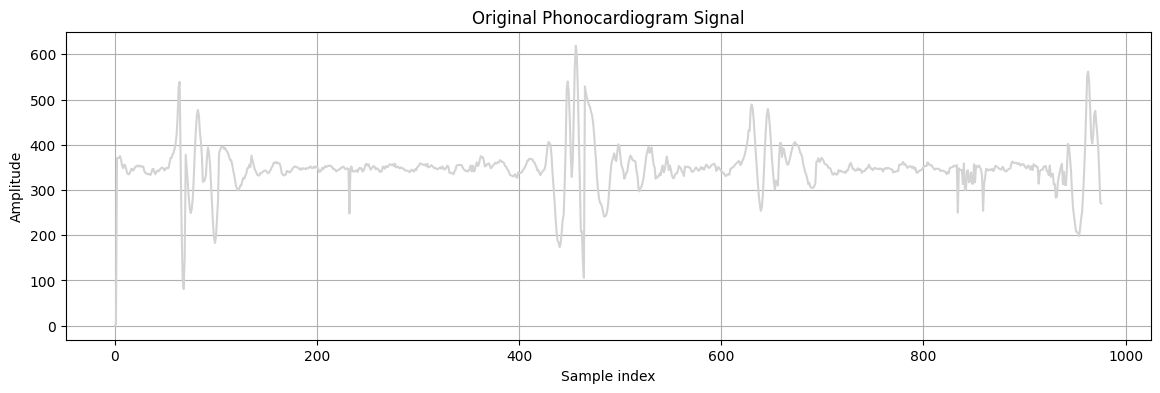

In [191]:
plt.figure(figsize=(14, 4))
plt.plot(array, color="lightgray")
plt.title("Original Phonocardiogram Signal")
plt.xlabel("Sample index")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

## Signal Centering

To remove the constant (DC) component of the phonocardiogram signal, the signal is centered by subtracting its mean value. This operation shifts the signal so that its average value becomes zero.

The centering operation can be expressed as:

$$x_{sh}(n) = x(n) - M_x$$

where:

- $x(n)$ is the original signal  
- $M_x$ is the mean value of the signal

Signal centering is an important preprocessing step because it removes the baseline offset and simplifies further signal analysis.

In [192]:
from numpy import mean
import matplotlib.pyplot as plt

# Compute mean value
med = mean(array)

# Center the signal
array = [x - med for x in array]

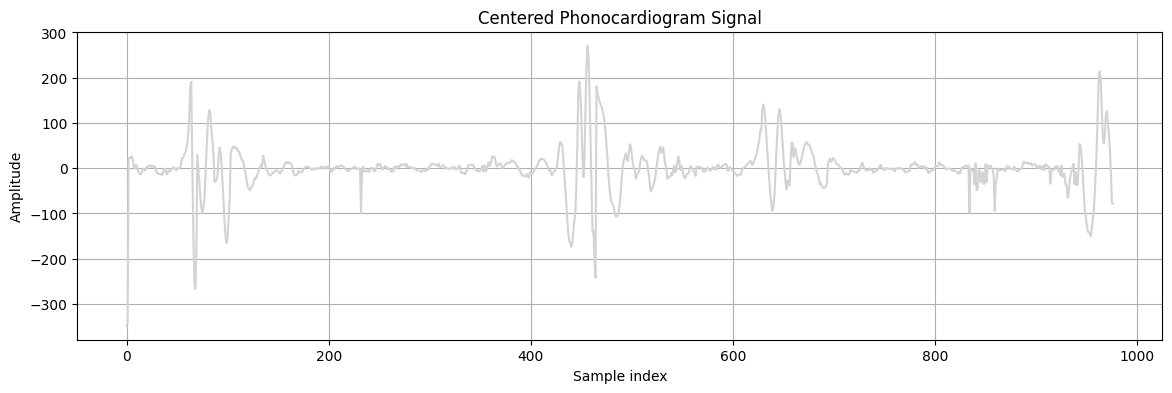

In [193]:
plt.figure(figsize=(14, 4))
plt.plot(array, color="lightgray")
plt.title("Centered Phonocardiogram Signal")
plt.xlabel("Sample index")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

## Envelope Extraction

To improve the stability of the algorithm, the absolute value of the centered signal is used.  
This operation highlights the magnitude of the signal and simplifies the detection of the heart sound components.

The envelope of the signal is computed as

$\[
x_t(n) = |x_{sh}(n)|
\]$

where $\(x_{sh}(n)\)$ is the centered signal.

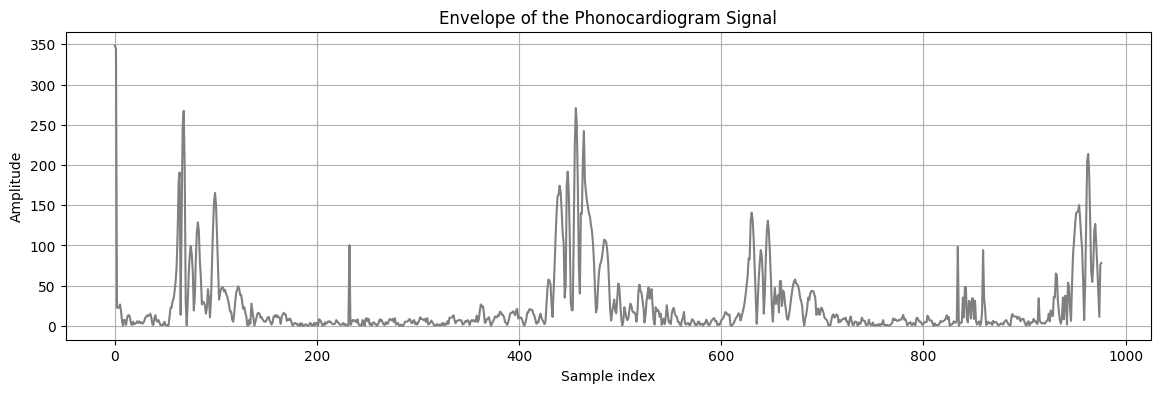

In [194]:
import numpy as np
import matplotlib.pyplot as plt

# ensure numpy array
array = np.array(array)

# envelope extraction
envelope = np.abs(array)

plt.figure(figsize=(14,4))
plt.plot(envelope, color="gray")

plt.title("Envelope of the Phonocardiogram Signal")
plt.xlabel("Sample index")
plt.ylabel("Amplitude")

plt.grid(True)
plt.show()

## Step 2: Moving Average Smoothing
   
To reduce high-frequency fluctuations and noise in the signal, a moving average filter is applied.  
The moving average smoothing helps emphasize the main structures of the phonocardiogram signal and improves the stability of further detection steps.

The moving average filter is defined as:

$$
P(n) = \frac{1}{w}\sum_{m=0}^{w-1} x_t(n+m)
$$

where:

- $x_t(n)$ — envelope of the signal  
- $w$ — window size  
- $P(n)$ — smoothed signal

The window size is selected experimentally in order to achieve a balance between noise suppression and preservation of signal features.

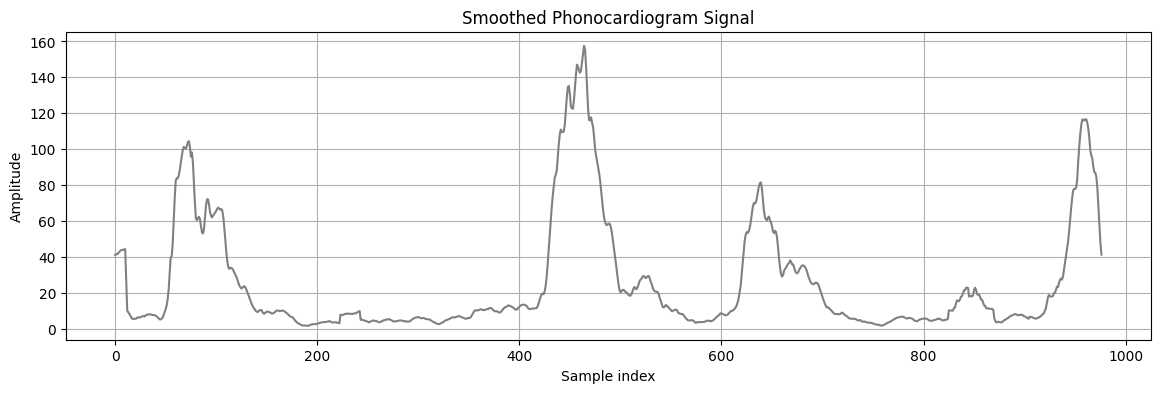

In [217]:
import numpy as np
import matplotlib.pyplot as plt

# envelope extraction
envelope = np.abs(array)

# moving average function
def moving_average(signal, window=20):
    return np.convolve(signal, np.ones(window) / window, mode='same')

# smoothing the envelope signal
smoothed_signal = moving_average(envelope)

plt.figure(figsize=(14,4))
plt.plot(smoothed_signal, color="gray")

plt.title("Smoothed Phonocardiogram Signal")
plt.xlabel("Sample index")
plt.ylabel("Amplitude")

plt.grid(True)
plt.show()

## Step 3: Noise Suppression

To separate signal components from the background noise, threshold filtering is applied. The threshold is calculated from the mean value and the standard deviation of the smoothed signal.

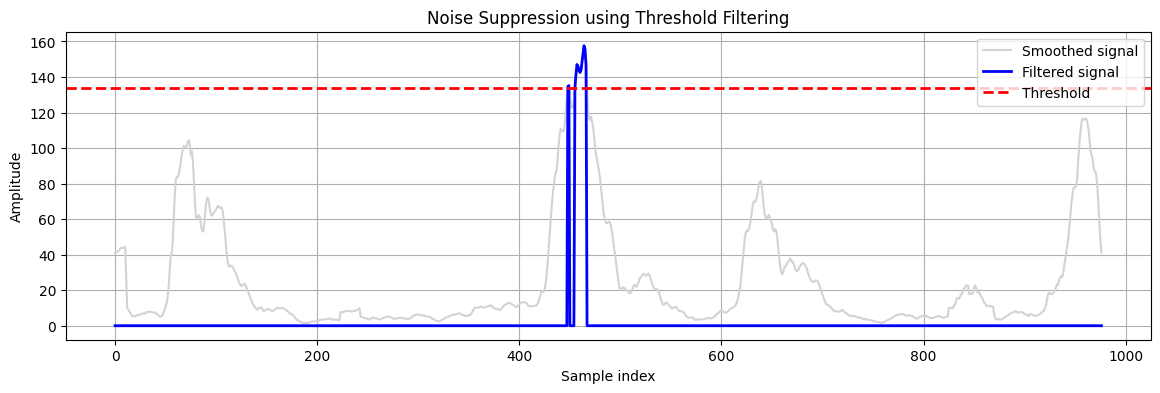

In [196]:
import numpy as np
import matplotlib.pyplot as plt

def remove_noise(signal, threshold_ratio=0.7):
    threshold = threshold_ratio * np.max(signal)
    filtered = np.where(signal >= threshold, signal, 0)
    return filtered, threshold


filtered, threshold = remove_noise(smoothed_signal, threshold_ratio=0.85)

plt.figure(figsize=(14,4))

plt.plot(smoothed_signal, color="lightgray", label="Smoothed signal")
plt.plot(filtered, color="blue", linewidth=2, label="Filtered signal")

plt.axhline(threshold, color="red", linestyle="--", linewidth=2, label="Threshold")

plt.legend()
plt.grid(True)

plt.title("Noise Suppression using Threshold Filtering")
plt.xlabel("Sample index")
plt.ylabel("Amplitude")

plt.show()

## Step 4: Detection of Tone Boundaries

After thresholding, the non-zero intervals of the filtered signal are interpreted as candidate heart sound segments.

The beginning of a segment is detected when the signal changes from zero to a non-zero value.  
The end of a segment is detected when the signal changes from a non-zero value to zero.

Thus, each continuous non-zero interval corresponds to a candidate heart sound region, which can be analyzed further to determine its temporal boundaries and peak amplitude.

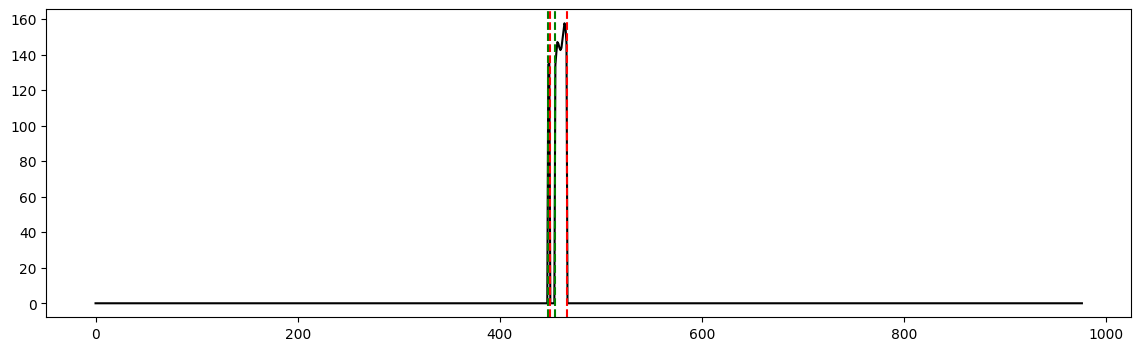

In [209]:
def detect_boundaries(signal, eps=1e-6):

    starts = []
    ends = []

    for i in range(1, len(signal)):

        # начало интервала
        if signal[i-1] <= eps and signal[i] > eps:
            starts.append(i)

        # конец интервала
        if signal[i-1] > eps and signal[i] <= eps:
            ends.append(i)

    # если последний интервал не закрыт
    if len(starts) > len(ends):
        ends.append(len(signal)-1)

    return starts, ends

plt.figure(figsize=(14, 4))
plt.plot(filtered, color="black", label="Filtered signal")

for s in starts:
    plt.axvline(s, color="green", linestyle="--", label="Start" if s == starts[0] else "")
for e in ends:
    plt.axvline(e, color="red", linestyle="--", label="End" if e == ends[0] else "")



The obtained graph correctly reflects the operation of the proposed threshold-based detection algorithm. The non-zero intervals correspond to candidate heart sound regions whose boundaries are determined by the selected threshold. At the same time, the exact physiological duration of the tones may differ from the detected intervals due to the simplicity of the method.

In [198]:
starts, ends = detect_boundaries(filtered)

print(starts)
print(ends)

[448, 455]
[450, 467]


## Step 5: Peak Detection Inside Each Interval

After detecting the boundaries of candidate heart sound intervals, the next step is to determine the point of maximum amplitude within each interval.

For each detected interval, the index of the maximum signal value is calculated. This point corresponds to the peak of the heart sound.

Thus, each detected heart sound can be represented by three characteristic points:

- $t_1$ — beginning of the tone  
- $t_2$ — point of maximum amplitude  
- $t_3$ — end of the tone

These three points form a triplet that describes the temporal structure of the detected heart sound.

In [199]:
def detect_peaks(signal, starts, ends):

    peaks = []

    for s, e in zip(starts, ends):

        if e > s:
            segment = signal[s:e]
            peak_index = np.argmax(segment) + s
            peaks.append(peak_index)

    return peaks

In [200]:
peaks = detect_peaks(filtered, starts, ends)

In [201]:
triplets = [[int(s), int(p), int(e)] for s, p, e in zip(starts, peaks, ends)]

print("Detected heart sounds:")
print(triplets)

Detected heart sounds:
[[448, 449, 450], [455, 464, 467]]


In [202]:
peaks = [int(p) for p in peaks]

print("Peaks:", peaks)

Peaks: [449, 464]


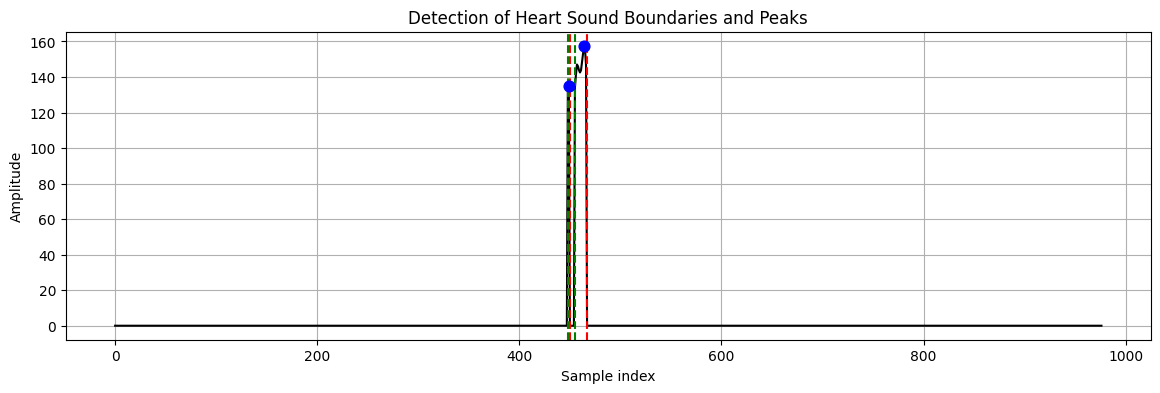

In [203]:
plt.figure(figsize=(14,4))

plt.plot(filtered, color="black", label="Filtered signal")

for s in starts:
    plt.axvline(s, color="green", linestyle="--")

for e in ends:
    plt.axvline(e, color="red", linestyle="--")

for p in peaks:
    plt.scatter(p, filtered[p], color="blue", s=60, zorder=3)

plt.title("Detection of Heart Sound Boundaries and Peaks")
plt.xlabel("Sample index")
plt.ylabel("Amplitude")

plt.grid(True)
plt.show()

In [210]:
triplets = [[int(s), int(p), int(e)] for s, p, e in zip(starts, peaks, ends)]
print(triplets)

[[448, 449, 450], [455, 464, 467]]


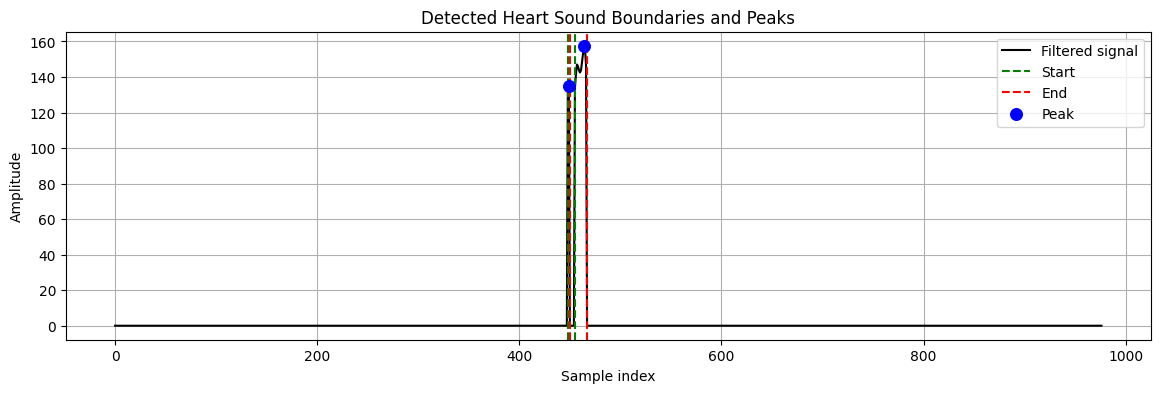

In [211]:
plt.figure(figsize=(14,4))

plt.plot(filtered, color="black", label="Filtered signal")

for i, s in enumerate(starts):
    plt.axvline(s, color="green", linestyle="--", label="Start" if i == 0 else "")

for i, e in enumerate(ends):
    plt.axvline(e, color="red", linestyle="--", label="End" if i == 0 else "")

for i, p in enumerate(peaks):
    plt.scatter(p, filtered[p], color="blue", s=70, zorder=3, label="Peak" if i == 0 else "")

plt.title("Detected Heart Sound Boundaries and Peaks")
plt.xlabel("Sample index")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.show()

## Conversion from Sample Index to Time

Since the sampling frequency of the signal is **1000 Hz**, one sample corresponds to a time interval of **0.001 seconds**.

The time corresponding to a given sample index can be calculated using the following relation:

$$
t = \frac{n}{f_s}
$$

where:

- $t$ — time in seconds  
- $n$ — sample index  
- $f_s$ — sampling frequency

For this project:

$$
f_s = 1000 \text{ Hz}
$$

Therefore:

$$
t = n \times 0.001
$$

This conversion allows the detected indices $t_1$, $t_2$, and $t_3$ to be expressed in seconds instead of sample numbers.

In [212]:
fs = 1000  # sampling frequency

triplets_time = [[s/fs, p/fs, e/fs] for s, p, e in triplets]

print("Heart sounds in seconds:")
print(triplets_time)

Heart sounds in seconds:
[[0.448, 0.449, 0.45], [0.455, 0.464, 0.467]]


## Frequency-Domain Analysis

Although the main task of this project is the localization of heart tones in the time domain, it is also useful to analyze the signal in the frequency domain.

This can be done using the Fast Fourier Transform (FFT), which converts the signal from the time domain into its frequency representation.

The discrete Fourier transform can be expressed as:

$$
S(k) = \frac{1}{N}\sum_{n=0}^{N-1} s(n)e^{-j2\pi nk/N}
$$

where:

- $s(n)$ — input signal  
- $N$ — number of samples  
- $k$ — frequency index

The frequency-domain representation allows us to observe the spectral components of the phonocardiogram signal and to identify dominant frequency ranges associated with heart sounds.

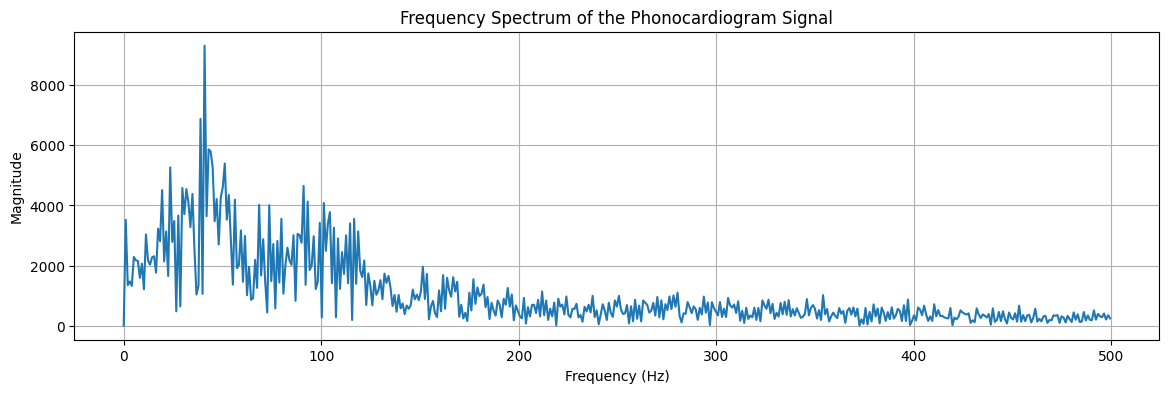

In [216]:
import numpy as np
import matplotlib.pyplot as plt

fs = 1000  # sampling frequency

# remove DC component
signal = array - np.mean(array)

# FFT
fft_values = np.fft.fft(signal)
freqs = np.fft.fftfreq(len(signal), 1/fs)

# positive frequencies
mask = freqs >= 0

plt.figure(figsize=(14,4))
plt.plot(freqs[mask], np.abs(fft_values[mask]))

plt.title("Frequency Spectrum of the Phonocardiogram Signal")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")

plt.grid(True)
plt.show()

## Conclusion

In this project, a software tool for phonocardiogram signal processing was developed using the Python programming language.

The proposed algorithm includes several stages: signal centering, envelope extraction, moving average smoothing, threshold-based filtering, and automatic detection of the boundaries of the first heart sound.

The resulting system provides both a numerical representation of the detected tones in the form of triplets \([t_1, t_2, t_3]\) and a visual interpretation of the results on the signal graph.

The obtained results demonstrate that mathematical methods and digital signal processing techniques can be effectively applied to biomedical signal analysis.

The developed approach can serve as a basis for further research and improvement of automated heart sound analysis systems.